# Comparación de Modelos — Clasificador de Noticias (Caso 9)

Proyecto Final · Módulo de PLN

Este notebook compara los tres modelos entrenados (Naive Bayes, Logistic Regression, Transformer ELECTRA) sobre el mismo set de test, mostrando métricas y matrices de confusión.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'backend'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from data.generate_dataset import cargar_dataset, CATEGORIAS
from pipeline.models_classic import cargar_modelo

MODELS = os.path.join('..', 'backend', 'models')
DATA = os.path.join('..', 'backend', 'data')

test = cargar_dataset(os.path.join(DATA, 'test.json'))
textos = [n['texto'] for n in test]
y_true = [n['categoria'] for n in test]
labels = CATEGORIAS
print(f'Test: {len(textos)} muestras, {len(labels)} categorias')

Test: 224 muestras, 7 categorias


## 1. Naive Bayes Multinomial (TF-IDF)

In [2]:
nb = cargar_modelo(os.path.join(MODELS, 'nb_multinomial.pkl'))
y_nb = nb.predict(textos)
acc_nb = accuracy_score(y_true, y_nb)
p_nb, r_nb, f1_nb, _ = precision_recall_fscore_support(y_true, y_nb, average='macro', zero_division=0)
print(f'Accuracy: {acc_nb:.4f} | Precision: {p_nb:.4f} | Recall: {r_nb:.4f} | F1: {f1_nb:.4f}')

c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MultinomialNB from version 1.9.0 when using version 1.7.2. This might lead to bre

Accuracy: 0.9732 | Precision: 0.9741 | Recall: 0.9732 | F1: 0.9733


## 2. Logistic Regression (TF-IDF)

In [3]:
logreg = cargar_modelo(os.path.join(MODELS, 'logreg.pkl'))
y_lr = logreg.predict(textos)
acc_lr = accuracy_score(y_true, y_lr)
p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_true, y_lr, average='macro', zero_division=0)
print(f'Accuracy: {acc_lr:.4f} | Precision: {p_lr:.4f} | Recall: {r_lr:.4f} | F1: {f1_lr:.4f}')

c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Mark50\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.7.2. This might lead t

Accuracy: 0.9821 | Precision: 0.9829 | Recall: 0.9821 | F1: 0.9821


## 3. Transformer (ELECTRA-small afinado)

In [4]:
from pipeline.transformer import cargar_modelo as cargar_trans, predecir

model_tr, tok_tr = cargar_trans(model_path=os.path.join(MODELS, 'transformer'))
resultados_tr = predecir(model_tr, tok_tr, textos)
y_tr = [r['label'] for r in resultados_tr]
acc_tr = accuracy_score(y_true, y_tr)
p_tr, r_tr, f1_tr, _ = precision_recall_fscore_support(y_true, y_tr, average='macro', zero_division=0)
print(f'Accuracy: {acc_tr:.4f} | Precision: {p_tr:.4f} | Recall: {r_tr:.4f} | F1: {f1_tr:.4f}')

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000


## 4. Tabla comparativa

In [5]:
tabla = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Logistic Regression', 'Transformer (ELECTRA)'],
    'Tipo': ['Clasico', 'Clasico', 'Neuronal'],
    'Accuracy': [acc_nb, acc_lr, acc_tr],
    'Precision': [p_nb, p_lr, p_tr],
    'Recall': [r_nb, r_lr, r_tr],
    'F1': [f1_nb, f1_lr, f1_tr],
})
tabla

,Modelo,Tipo,Accuracy,Precision,Recall,F1
0,Naive Bayes,Clasico,0.973214,0.974145,0.973214,0.973272
1,Logistic Regression,Clasico,0.982143,0.982939,0.982143,0.982059
2,Transformer (ELECTRA),Neuronal,1.000000,1.000000,1.000000,1.000000


## 5. Matrices de confusión

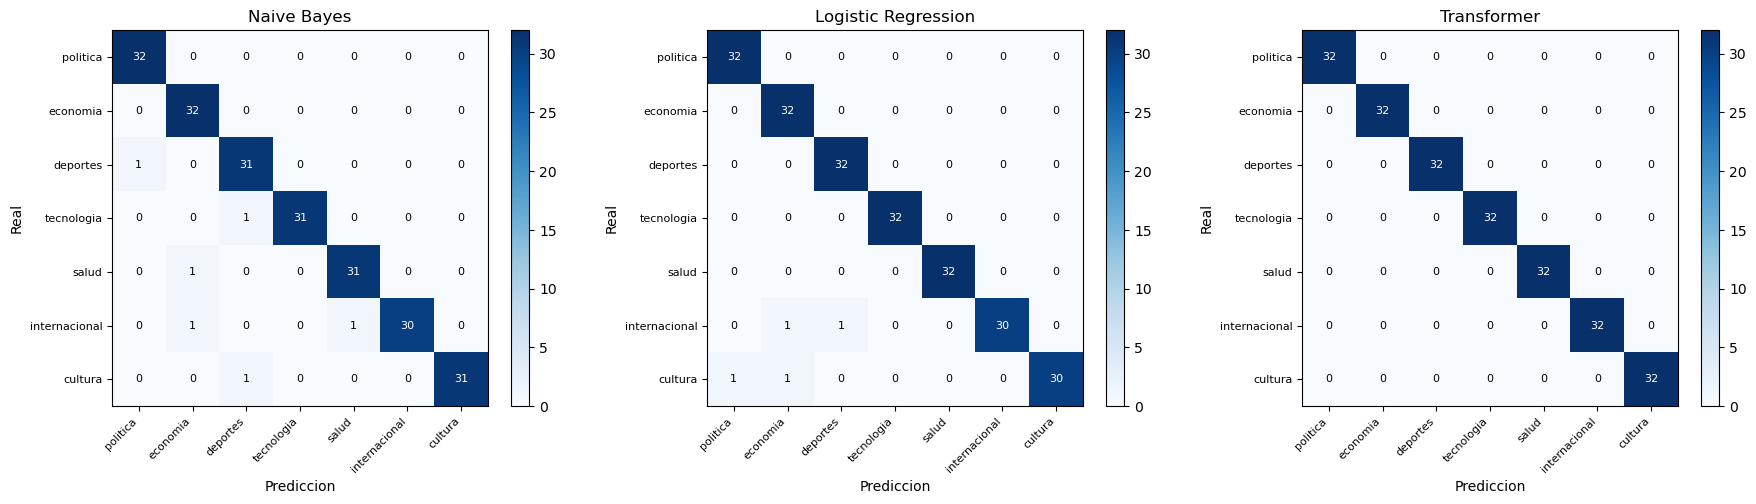

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, y_pred) in zip(axes, [
    ('Naive Bayes', y_nb), ('Logistic Regression', y_lr), ('Transformer', y_tr)
]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(nombre)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'comparison_confusion.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Análisis de errores

Examinamos los casos donde los modelos clásicos fallan pero el Transformer acierta.

In [7]:
errores = []
for i in range(len(textos)):
    if y_nb[i] != y_true[i] or y_lr[i] != y_true[i]:
        errores.append({
            'texto': textos[i][:80],
            'real': y_true[i],
            'NB': y_nb[i],
            'LR': y_lr[i],
            'Transformer': y_tr[i],
        })
pd.DataFrame(errores)

,texto,real,NB,LR,Transformer
0,"El secreto mejor guardado:, la union europea c...",internacional,economia,economia,internacional
1,La agencia espacial advirtio que la situacion ...,tecnologia,deportes,tecnologia,tecnologia
2,La revista literaria llamo a la unidad y al tr...,cultura,deportes,politica,cultura
3,"ESCANDALO total al descubrirse, la sociedad me...",salud,economia,salud,salud
4,"URGENTE: alertan que, el alto comisionado info...",internacional,salud,deportes,internacional
5,"NO CREERAS lo que paso, la liga profesional an...",deportes,politica,deportes,deportes
6,"EXCLUSIVO: filtran que, el instituto de cultur...",cultura,cultura,economia,cultura
